In [1]:
from typing import List,TypedDict,Literal
from dotenv import load_dotenv

from pydantic import BaseModel, Field
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import Chroma,FAISS
from langchain_huggingface import HuggingFaceEmbeddings,ChatHuggingFace,HuggingFaceEndpoint
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_core.output_parsers import PydanticOutputParser

from langgraph.graph import StateGraph,END,START

load_dotenv()

C:\Users\adarsh\AppData\Local\Temp\ipykernel_14784\2241993529.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\adarsh\OneDrive\Desktop\langraph\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
docs=PyPDFLoader(r"C:\Users\adarsh\OneDrive\Desktop\langraph\SELF-RAG\Imaginary_Company_Profile.pdf").load()

In [3]:
chunks=RecursiveCharacterTextSplitter(chunk_size=100,chunk_overlap=10).split_documents(docs)

In [4]:
for d in chunks:
    d.page_content=d.page_content.encode("utf-8","ignore").decode("utf-8","igone")

In [5]:
emmbeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_store=FAISS.from_documents(chunks,emmbeddings)
retriever=vector_store.as_retriever(search_kwargs={"k":3})

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2854.70it/s]


In [6]:
llm=HuggingFaceEndpoint(
    repo_id='Qwen/Qwen2.5-7B-Instruct',
    task='text-generation',
    max_new_tokens=2048
)

model=ChatHuggingFace(llm=llm,streaming=True)

In [7]:
class State(TypedDict):
    question:str

    need_retrieval:bool

    docs:List[Document]
    relevant_docs:List[Document]
    answer:str

In [8]:
class RetrieveDecision(BaseModel):
    should_retrieve:bool=Field(
        ...,
        description="True if external documents are needed to answer reliably, False otherwise"
    )

parser=PydanticOutputParser(pydantic_object=RetrieveDecision)

decide_retrieval_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "you decide whether retrieval is needed.\n"
            "Return a JSON  object tht matches this schema:\n"
            "{{'should_retrieve':bool}}\n\n"
            "Guidelines:\n"
            "-should_retireve=True if the answering requires specific facts,citations or info likley not in the model\n"
            "should_retrieve=False for general explanations,definitions ore reasoning that does not need sources.\n"
            "-if unsure ,choose true"

            "{format_instructions}"
        ),
        ("human","Question:{question}"),

    ]
)

def decision_retrieve(state:State):

    question=state["question"]

    prompt_val=decide_retrieval_prompt.invoke(
        {
            "question":question,
            "format_instructions":parser.get_format_instructions()
        }
    )
    out=model.invoke(prompt_val)
    result=parser.parse(out.content)

    return {"need_retrieval":result.should_retrieve}


In [9]:
direct_generation_prompt=ChatPromptTemplate.from_messages(
    [
    (
        "system",
        "Answer the question using your general Knowledge.\n"
        "do Not assume acces to external document"
        "if you are ensure or the answer requires specific sources,say:\n"
        "I dont know based on my general Knowledge"
    ),
    ("human","question:{question}")
    ]

)

def generate_direct(state:State):

    template=direct_generation_prompt.invoke({"question":state["question"]})

    out=model.invoke(template)
    return{"answer":out.content}

In [10]:
def retrieve(state:State):
    return {"docs":retriever.invoke(state["question"])}


In [11]:
class RelevanceDecision(BaseModel):
    is_relevant:bool=Field(
        ...,
        description="True if document helps answer the question,else false"
    )

parser2=PydanticOutputParser(pydantic_object=RelevanceDecision)

is_relevant_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Yoy are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant':boolean}}\n\n"
            "A document is relevant if it contains informations useful for answering the question."

            "{format_instructions}"

        ),
        (
            "human",
            "Question:{question}\n\n Document:{document}"
        )

    ]


)

def is_relevant(state:State):

    relevant_docs:List[Document]=[]


    for d in state["docs"]:
        prompt=is_relevant_prompt.invoke(
            {
                "question":state["question"],
                "document":d,
                "format_instructions":parser2.get_format_instructions()
            }
        )

        out=model.invoke(prompt)
        result=parser2.parse(out.content)

        if  result.is_relevant:
            relevant_docs.append(d)

    return {"relevant_docs":relevant_docs}


    

In [12]:
answer_relevent_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "generate a favaorable answer of the question based on the document given to you"
            "Note-use documen tto answer the question"
        ),
        ("human","question:{question}\n ducument:{document}")

    ]
)

def generate_from_context(state:State):

    question=state["question"]

    context="\n\n".join(d.page_content for d in state["relevant_docs"]).strip()

    template=answer_relevent_prompt.invoke(
        {
            "question":question,
            "document":context
        }
    )
    output=model.invoke(template)

    return{"answer":output.content}

In [13]:
def no_relevant_docs(state:State):

    return {"answer":"no relevent answer is presentin the docs"}

In [41]:
def route_after_relevant(state:State):

    if State["relevant_docs"] and len(state["relevant_docs"])>0:
        return "generate_from_context"
    return "no_relevant_docs"

In [ ]:
def route_after_decide(state:State):
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [42]:
g=StateGraph(State)
g.add_node("decision_retrieve",decision_retrieve)
g.add_node("generate_direct",generate_direct)
g.add_node("retrieve",retrieve)
g.add_node("is_relevant",is_relevant)
g.add_node("generate_from_context",generate_from_context)
g.add_node("no_relevant_docs",no_relevant_docs)

g.add_edge(START,"decision_retrieve")
g.add_conditional_edges(
    "decision_retrieve",
    route_after_decide,
    {
        "retrieve":"retrieve",
        "generate_direct":"generate_direct"
    }

)
g.add_edge("retrieve","is_relevant")
g.add_conditional_edges(
    "is_relevant",
    route_after_relevant,
    {
        "generate_from_context":"generate_from_context",
        "no_relevant_docs":"no_relevant_docs"
    }

)
g.add_edge("generate_from_context",END)
g.add_edge("no_relevant_docs",END)
g.add_edge("generate_direct",END)



In [43]:
app=g.compile()

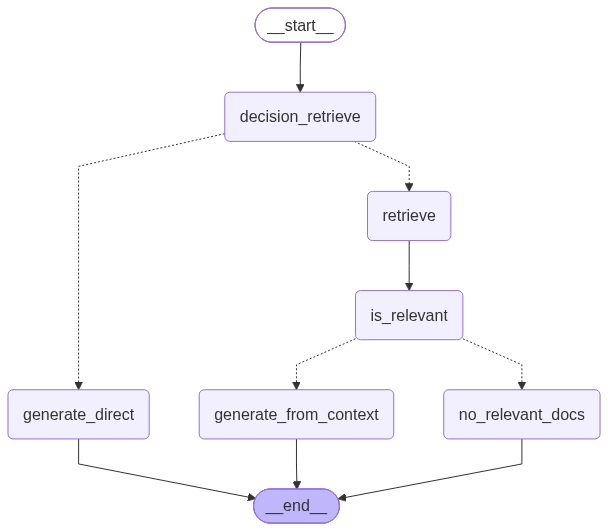

In [20]:
app

In [44]:
res=app.invoke(
    {
        "question":"what are the policies of the company",
        "need_retrieval":False,
        "docs":[],
        "relevant_docs":[],
        "answer":""    
        }
)

In [45]:
print(res["docs"])

[Document(id='ae1556dd-3780-4e2c-bd30-8b7b7a9729a6', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-05T03:51:53+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-05T03:51:53+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'C:\\Users\\adarsh\\OneDrive\\Desktop\\langraph\\SELF-RAG\\Imaginary_Company_Profile.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='policies, respect colleagues, avoid discrimination or harassment, use company resources'), Document(id='ef9da42c-1809-4949-bbce-726a8a84b0a9', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-05T03:51:53+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-05T03:51:53+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'C:\\Users\\adarsh\\OneDrive\\Desktop\\langraph\\SEL

In [46]:
print(res["relevant_docs"])

[Document(id='ae1556dd-3780-4e2c-bd30-8b7b7a9729a6', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-05T03:51:53+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-05T03:51:53+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'C:\\Users\\adarsh\\OneDrive\\Desktop\\langraph\\SELF-RAG\\Imaginary_Company_Profile.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='policies, respect colleagues, avoid discrimination or harassment, use company resources')]


In [47]:
print(res["answer"])

Based on the document provided, the company policies include:

1. Respecting colleagues.
2. Avoiding discrimination or harassment.
3. Using company resources appropriately.


In [48]:
res2=app.invoke(
    {
        "question":"what is the refund policy of the company",
        "need_retrieval":False,
        "docs":[],
        "relevant_docs":[],
        "answer":""    
        }
)

In [49]:
print(res2["answer"])

no relevent answer is presentin the docs


In [50]:
print(res2["docs"])

[Document(id='b595353e-08e5-42fe-a29e-069e119ec51a', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-05T03:51:53+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-05T03:51:53+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'C:\\Users\\adarsh\\OneDrive\\Desktop\\langraph\\SELF-RAG\\Imaginary_Company_Profile.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='explain their position before final decisions.\nHR Policies'), Document(id='26c55d59-0ab5-4786-9fa6-170c514c6887', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-05T03:51:53+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-05T03:51:53+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'C:\\Users\\adarsh\\OneDrive\\Desktop\\langraph\\SELF-RAG\\Imaginary_Company_Pro

In [51]:
print(res2["relevant_docs"])

[]
